In [ ]:
!pip install ultralytics easyocr opencv-python matplotlib pandas --quiet


In [ ]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from ultralytics import YOLO
import easyocr


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# === PATH CONFIG ===
# Folder with your full feedlot images (original images)
IMAGES_DIR = Path("/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/image")

# YOLO model that has an "ear_tag" (or similar) class
YOLO_MODEL_PATH = Path("/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/runs_optionA/y11n_cattle_ear_muzzle_adamw_aug3/weights/best.pt")

# Output folders
OUTPUT_BASE = Path("/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/ear_tag_ocr_output")
CROPS_DIR = OUTPUT_BASE / "ear_tag_crops"
ANNOTATED_DIR = OUTPUT_BASE / "annotated_images"
CSV_PATH = OUTPUT_BASE / "ear_tag_ocr_results.csv"

for p in [OUTPUT_BASE, CROPS_DIR, ANNOTATED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Class name for ear tag in your YOLO model
EAR_TAG_CLASS_NAME = "ear-tag"  # change if needed (e.g., "ear", "tag", etc.)

# OCR settings
OCR_LANGS = ['en']  # English; OCR will still read digits
DIGIT_ONLY = True   # If True, filter OCR results to digits only


In [ ]:
# Load YOLO ear-tag detector
yolo_model = YOLO(str(YOLO_MODEL_PATH))

# Load EasyOCR reader (GPU=True if you want, but CPU also works)
reader = easyocr.Reader(OCR_LANGS, gpu=True)  # set gpu=False if you don't have GPU


In [ ]:
#5.1 Visualization helper
def show_image_rgb(img_bgr, title=None, size=(8, 8)):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=size)
    plt.imshow(img_rgb)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


In [ ]:
#5.2 Function to filter OCR text to digits only
import re

def keep_digits_only(text: str) -> str:
    """Keep only digits from OCR output if DIGIT_ONLY is True."""
    if not DIGIT_ONLY:
        return text
    return ''.join(re.findall(r'\d', text))

In [ ]:
#5.3 Run YOLO detection and return ear-tag boxes
def detect_ear_tags(image_path: Path):
    """
    Run YOLO on a single image and return list of detections for the ear tag class.
    Each detection: dict with x1, y1, x2, y2, conf, class_id, class_name
    """
    results = yolo_model(str(image_path))  # list-like, one element per image
    detections = []

    # Assuming single image -> results[0]
    r = results[0]
    if r.boxes is None or len(r.boxes) == 0:
        return detections

    names = r.names  # class id to name mapping

    for box in r.boxes:
        cls_id = int(box.cls[0].item())
        cls_name = names[cls_id]
        if cls_name != EAR_TAG_CLASS_NAME:
            continue

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = float(box.conf[0].item())
        detections.append({
            "x1": int(x1),
            "y1": int(y1),
            "x2": int(x2),
            "y2": int(y2),
            "conf": conf,
            "class_id": cls_id,
            "class_name": cls_name
        })
    return detections


In [ ]:
#5.4 Crop ear tag regions and save
def crop_and_save_ear_tag(image_bgr, det, image_name_stem, idx):
    """
    Crop ear tag region from full image using detection dict and save to CROPS_DIR.
    Returns crop image (BGR) and crop_path.
    """
    x1, y1, x2, y2 = det["x1"], det["y1"], det["x2"], det["y2"]
    crop = image_bgr[y1:y2, x1:x2]

    crop_filename = f"{image_name_stem}_tag_{idx:02d}.jpg"
    crop_path = CROPS_DIR / crop_filename
    cv2.imwrite(str(crop_path), crop)

    return crop, crop_path

In [ ]:
#5.5 Run OCR on one crop
def ocr_on_crop(crop_bgr):
    """
    Run EasyOCR on a crop and return:
      - best_text: final text (possibly digits only)
      - best_conf: confidence score
    If nothing is detected, returns ("", 0.0)
    """
    # EasyOCR expects RGB or grayscale
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

    results = reader.readtext(crop_rgb)
    if len(results) == 0:
        return "", 0.0

    # results: list of [bbox, text, confidence]
    # Pick the result with highest confidence
    best = max(results, key=lambda r: r[2])
    text_raw = best[1]
    conf = float(best[2])

    # Optionally filter to digits only
    text_clean = keep_digits_only(text_raw)

    return text_clean, conf


In [ ]:
#5.6 Draw bounding box + text on original image
def draw_box_with_text(image_bgr, det, text, color=(0, 255, 0)):
    """
    Draw rectangle + text label on image (in-place).
    """
    x1, y1, x2, y2 = det["x1"], det["y1"], det["x2"], det["y2"]

    # Draw rectangle
    cv2.rectangle(image_bgr, (x1, y1), (x2, y2), color, 2)

    label = text if text else "unknown"
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.8
    thickness = 2

    # Put text above the box
    text_size, _ = cv2.getTextSize(label, font, font_scale, thickness)
    text_w, text_h = text_size

    # Make background rectangle for text for better visibility
    cv2.rectangle(image_bgr, (x1, y1 - text_h - 6), (x1 + text_w + 4, y1), color, -1)
    cv2.putText(image_bgr, label, (x1 + 2, y1 - 4), font, font_scale, (0, 0, 0), thickness, cv2.LINE_AA)


In [ ]:
#6. Main pipeline: process all images, save outputs & CSV
all_records = []

image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
len(image_paths)


4351

In [ ]:
for img_path in image_paths:
    print(f"Processing: {img_path.name}")

    # Read full image
    image_bgr = cv2.imread(str(img_path))
    if image_bgr is None:
        print("  Could not read image, skipping.")
        continue

    # 1) Detect ear tags
    detections = detect_ear_tags(img_path)

    if len(detections) == 0:
        print("  No ear tags detected.")
        continue

    # 2) For each detection: crop, OCR, draw, and record
    img_stem = img_path.stem

    for i, det in enumerate(detections, start=1):
        # Crop ear tag
        crop_bgr, crop_path = crop_and_save_ear_tag(image_bgr, det, img_stem, i)

        # Run OCR
        ocr_text, ocr_conf = ocr_on_crop(crop_bgr)

        # Draw on original image
        draw_box_with_text(image_bgr, det, ocr_text)

        # Save record for CSV
        rec = {
            "image_name": img_path.name,
            "image_path": str(img_path),
            "crop_name": crop_path.name,
            "crop_path": str(crop_path),
            "bbox_x1": det["x1"],
            "bbox_y1": det["y1"],
            "bbox_x2": det["x2"],
            "bbox_y2": det["y2"],
            "det_confidence": det["conf"],
            "ocr_text": ocr_text,
            "ocr_confidence": ocr_conf
        }
        all_records.append(rec)

    # 3) Save annotated image
    annotated_name = f"{img_stem}_annotated.jpg"
    annotated_path = ANNOTATED_DIR / annotated_name
    cv2.imwrite(str(annotated_path), image_bgr)

print("Done processing all images.")


Streaming output truncated to the last 5000 lines.
Processing: DSCF8160.JPG

image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/image/DSCF8160.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.2ms
Speed: 2.8ms preprocess, 8.2ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Processing: DSCF8161.JPG

image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/image/DSCF8161.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.3ms
Speed: 2.9ms preprocess, 8.3ms inference, 2.4ms postprocess per image at shape (1, 3, 448, 640)
Processing: DSCF8162.JPG

image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/image/DSCF8162.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle, 8.3ms
Speed: 2.9ms preprocess, 8.3ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
Processing: DSCF8163.JPG

image 1/1 /content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/image/DSCF8163.JPG: 448x640 1 cattle, 1 ear-tag, 1 muzzle,

In [ ]:
#6.1 Save results to CSV
df = pd.DataFrame(all_records)
df.to_csv(CSV_PATH, index=False)
df.head()


,image_name,image_path,crop_name,crop_path,bbox_x1,bbox_y1,bbox_x2,bbox_y2,det_confidence,ocr_text,ocr_confidence
0,DSCF0071.JPG,/content/drive/MyDrive/AGST 892/Final Project/...,DSCF0071_tag_01.jpg,/content/drive/MyDrive/AGST 892/Final Project/...,2410,202,3100,1057,0.895843,410,0.212000
1,DSCF0072.JPG,/content/drive/MyDrive/AGST 892/Final Project/...,DSCF0072_tag_01.jpg,/content/drive/MyDrive/AGST 892/Final Project/...,2408,200,3123,1060,0.906040,410,0.125867
2,DSCF0073.JPG,/content/drive/MyDrive/AGST 892/Final Project/...,DSCF0073_tag_01.jpg,/content/drive/MyDrive/AGST 892/Final Project/...,2413,199,3129,1056,0.908859,410,0.146951
3,DSCF0074.JPG,/content/drive/MyDrive/AGST 892/Final Project/...,DSCF0074_tag_01.jpg,/content/drive/MyDrive/AGST 892/Final Project/...,2414,195,3126,1050,0.914179,410,0.174281
4,DSCF0075.JPG,/content/drive/MyDrive/AGST 892/Final Project/...,DSCF0075_tag_01.jpg,/content/drive/MyDrive/AGST 892/Final Project/...,2418,90,3129,950,0.920135,410,0.209297


In [ ]:
def draw_box_with_text(image_bgr, x1, y1, x2, y2, text, color=(0, 255, 0)):
    """
    Draw rectangle + BIG text label on image (in-place).
    (Use this version if you are passing x1..y2 directly.)
    """
    # Box
    cv2.rectangle(image_bgr, (x1, y1), (x2, y2), color, 3)

    label = text if text else "unknown"

    # Make font scale depend on box size so it’s readable
    box_h = y2 - y1
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = max(1.0, box_h / 80.0)   # bigger number => bigger text
    thickness = 3

    # Text size and background rectangle
    (tw, th), _ = cv2.getTextSize(label, font, font_scale, thickness)

    # Put text just above the box, but clip if it goes off the top
    text_x1 = x1
    text_y1 = max(th + 10, y1)  # ensure room

    cv2.rectangle(
        image_bgr,
        (text_x1, text_y1 - th - 8),
        (text_x1 + tw + 8, text_y1),
        color,
        -1
    )
    cv2.putText(
        image_bgr,
        label,
        (text_x1 + 4, text_y1 - 4),
        font,
        font_scale,
        (0, 0, 0),
        thickness,
        cv2.LINE_AA,
    )


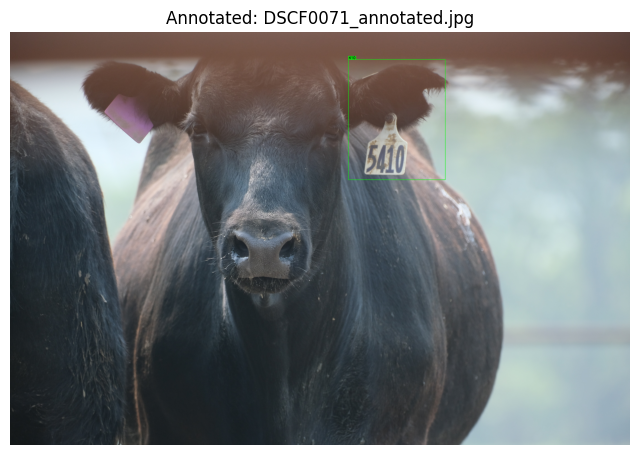

In [ ]:
#7. Quick visual check of some results
# Show one annotated image for sanity check
sample_ann = next(ANNOTATED_DIR.glob("*_annotated.jpg"), None)
if sample_ann is not None:
    img = cv2.imread(str(sample_ann))
    show_image_rgb(img, title=f"Annotated: {sample_ann.name}")
else:
    print("No annotated images found.")


In [ ]:
df = pd.DataFrame(all_records)
df.to_csv(CSV_PATH, index=False)
GT_CSV_PATH = "/content/drive/MyDrive/AGST 892/Final Project/Dataset/sorted data/ear_tag_ocr_output/ear_tag_gt.csv"
